# Evaluierung des SFT-Übersetzungsmodells auf dem Lebenshilfe-Datensatz (Decoder-Only)

Dieses Notebook evaluiert das **Supervised Fine-Tuned (SFT)** Decoder-Only Modell (`Qwen/Qwen2.5-7B-Instruct` mit LoRA und Leichte-Sprache-Systemprompt) auf dem unabhängigen **Lebenshilfe-Testdatensatz**:

1. **Modell- & Tokenizer-Initialisierung:** Lädt das Basismodell `Qwen/Qwen2.5-7B-Instruct` und hängt den SFT LoRA-Adapter aus `results/models/decoder_only/sft` an.
2. **Reward- & Metrik-Setup:**
   - **Stil & Einfachheit ($R_{\text{style}}$):** BiLSTM Regressor (Mixup).
   - **Semantische Ähnlichkeit ($R_{\text{sem}}$):** Jina SBERT Ähnlichkeit zur AS-Quelle.
   - **Referenz-Treue:** SBERT Ähnlichkeit zur echten menschlichen LS-Referenz.
   - **Composite Reward:** Kombinierter Qualitäts-Score ($R_{\text{total}} = w_{\text{style}} \cdot R_{\text{style}} + w_{\text{sem}} \cdot R_{\text{sem}}$).
3. **Batch-Übersetzung** aller Artikel des Lebenshilfe-Datensatzes mit dem offiziellen Leichte-Sprache-Systemprompt (Regeln W2–W11).
4. **Quantitative & Statistische Auswertung** (Mittelwert, Standardabweichung, Verteilungen & CSV-Export).
5. **Qualitatives Stichproben-Audit:** 1-zu-1 Gegenüberstellung der ersten Artikel.
6. **Visualisierung der Metrik-Verteilungen:** Boxplots und Composite-Reward Histogramme.
7. **Interaktiver Übersetzungstest:** Sofortige Übersetzung beliebiger Eingabetexte.

In [1]:
import os
import sys
import json
import glob
import random
import re
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import spacy
import textstat
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from sentence_transformers import SentenceTransformer, util

while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir("..")

print("Arbeitsverzeichnis:", os.getcwd())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Nutze Device: {DEVICE}")

Arbeitsverzeichnis: /home/fiete/master-thesis
Nutze Device: cuda


In [2]:
BASE_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
SFT_MODEL_PATH = "results/models/decoder_only/sft"
LH_DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset_clean.json"

# Reward-Modell & Vokabular (1000-Token-Metrik)
REWARD_MODEL_PATH = "results/models/token_length_exp/bilstm_mixup_regression_1024.pt"
REWARD_VOCAB_PATH = "data/token_length_exp/mixup_vocab_1024.json"

if not os.path.exists(REWARD_MODEL_PATH):
    REWARD_MODEL_PATH = "results/models/bilstm_mixup_regression.pt"
if not os.path.exists(REWARD_VOCAB_PATH):
    REWARD_VOCAB_PATH = "data/vocabs/mixup_vocab.json"

SBERT_MODEL_NAME = "jinaai/jina-embeddings-v2-base-de"
if not os.path.exists(REWARD_MODEL_PATH):
    SBERT_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

W_STYLE = 0.7
W_SEM = 0.3
MAX_SOURCE_LEN = 2048  # Erhöht, damit lange Lebenshilfe-Texte nicht abgeschnitten werden
MAX_TARGET_LEN = 1500

print(f"Base Model:            {BASE_MODEL_NAME}")
print(f"SFT Modell-Pfad:       {SFT_MODEL_PATH}")
print(f"Lebenshilfe-Datensatz: {LH_DATASET_PATH}")
print(f"Reward Modell:         {REWARD_MODEL_PATH}")
print(f"Reward Vokabular:      {REWARD_VOCAB_PATH}")
print(f"SBERT Modell:          {SBERT_MODEL_NAME}")

Base Model:            Qwen/Qwen2.5-1.5B-Instruct
SFT Modell-Pfad:       results/models/decoder_only/sft
Lebenshilfe-Datensatz: data/lebenshilfe/lebenshilfe_dataset_clean.json
Reward Modell:         results/models/bilstm_mixup_regression.pt
Reward Vokabular:      data/vocabs/mixup_vocab.json
SBERT Modell:          jinaai/jina-embeddings-v2-base-de


## 1. SFT-Modell & Tokenizer laden (Decoder-Only)

In [3]:
SYSTEM_PROMPT_LEICHTE_SPRACHE = """Du bist ein professioneller Übersetzer für deutsche Leichte Sprache. Deine einzige Aufgabe ist es, schwere deutsche Texte in verständliche Leichte Sprache nach den offiziellen Regeln zu übertragen.

WICHTIGE GRUNDREGELN ZUR INHALTSTREUE:
- W1 (Strikte Inhaltstreue): Übersetze NUR die Informationen, die tatsächlich im Ausgangstext stehen.
- KEINE ERFINDUNGEN: Erfinde unter keinen Umständen neue Angebote, Vereine, Broschüren, Orte, E-Mail-Adressen, Telefonnummern, Websites oder Kontaktboxen.
- Behalte alle Namen, Zahlen, Fakten und Daten aus dem Ausgangstext unverändert bei.
- Füge keine erfundenen Einstiegsfragen hinzu, wenn der Ausgangstext keine Fragen stellt.

REGELN DER LEICHTEN SPRACHE:
- W2 (Einfache Wörter): Benutze einfache und genaue Wörter. Vermeide schwere Fachbegriffe und Fremdwörter.
- W5 (Kurze Wörter): Benutze kurze, bekannte Wörter statt langer oder alter Begriffe.
- W6 (Keine Abkürzungen): Schreibe alle Wörter immer vollständig aus (z. B. "das heißt" statt "d. h.").
- W7 (Verbalstil): Verwende Verben (Tu-Wörter) und vermeide Hauptwort-Stil (Nominalstil).
- W8 (Aktiv): Schreibe im Aktiv. Benenne klar handelnde Personen und vermeide Passiv-Formen.
- W9 (Kein Genitiv): Vermeide den 2. Fall (Genitiv). Nutze stattdessen den 3. Fall (Dativ) mit "von" (z. B. "das Haus vom Lehrer").
- W10 (Kein Konjunktiv): Verwende keinen Konjunktiv. Nutze klare Aussagen oder Hilfswörter wie "vielleicht".
- W11 (Positiv formulieren): Formuliere Aussagen positiv und vermeide unnötige Verneinungen.

Erstelle ausschließlich die vereinfachte Übersetzung des Textes ohne zusätzliche Kommentare oder erfundene Inhalte."""

USER_INSTRUCTION_PREFIX = "Vereinfache folgenden Text in verständliche deutsche Leichte Sprache:\n\n"

def create_chat_messages(as_text, ls_text=None):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT_LEICHTE_SPRACHE},
        {"role": "user", "content": f"{USER_INSTRUCTION_PREFIX}{as_text.strip()}"},
    ]
    if ls_text is not None:
        messages.append({"role": "assistant", "content": ls_text.strip()})
    return messages

print("Lade Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"  # Wichtig für saubere Autoregressive Batch-Generierung

torch_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else (torch.float16 if torch.cuda.is_available() else torch.float32)

print(f"Lade Basis-Architektur: {BASE_MODEL_NAME} ({torch_dtype})...")
raw_base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    torch_dtype=torch_dtype,
    trust_remote_code=True,
    device_map="auto" if torch.cuda.is_available() else None,
)

print(f"Lade SFT LoRA-Adapter aus: {SFT_MODEL_PATH}...")
if os.path.exists(os.path.join(SFT_MODEL_PATH, "adapter_config.json")):
    sft_model = PeftModel.from_pretrained(raw_base_model, SFT_MODEL_PATH)
    sft_model.eval()
    print("SFT LoRA Adapter erfolgreich geladen!")
else:
    print(f"Warnung: SFT-Pfad {SFT_MODEL_PATH} nicht gefunden. Verwende Basismodell.")
    sft_model = raw_base_model

print("SFT-Modell und Tokenizer erfolgreich geladen!")

Lade Tokenizer...


`torch_dtype` is deprecated! Use `dtype` instead!


Lade Basis-Architektur: Qwen/Qwen2.5-1.5B-Instruct (torch.bfloat16)...
Lade SFT LoRA-Adapter aus: results/models/decoder_only/sft...
SFT LoRA Adapter erfolgreich geladen!
SFT-Modell und Tokenizer erfolgreich geladen!


## 2. Few-Shot In-Context Learning (ICL) Baseline Setup

In [4]:
FEW_SHOT_MODEL_NAME = "Vagosolutions/Llama-3-SauerkrautLM-8b-Instruct"
print(f"Lade deutsches 8B-Basismodell für Few-Shot Baseline: {FEW_SHOT_MODEL_NAME}...")

few_shot_tokenizer = AutoTokenizer.from_pretrained(FEW_SHOT_MODEL_NAME, trust_remote_code=True)
if few_shot_tokenizer.pad_token is None:
    few_shot_tokenizer.pad_token = few_shot_tokenizer.eos_token
few_shot_tokenizer.padding_side = "left"

few_shot_model = AutoModelForCausalLM.from_pretrained(
    FEW_SHOT_MODEL_NAME,
    torch_dtype=torch_dtype,
    trust_remote_code=True,
    device_map="auto" if torch.cuda.is_available() else None,
)
few_shot_model.eval()

FEW_SHOT_SYSTEM_PROMPT = """Du bist ein professioneller Übersetzer für deutsche Leichte Sprache.
Deine einzige Aufgabe ist es, den gegebenen Ausgangstext Satz für Satz in verständliche Leichte Sprache nach den offiziellen Regeln zu übertragen.

STRIKTE REGELN:
1. Satzbau: Schreibe NUR kurze Hauptsätze (maximal 6 bis 8 Wörter pro Satz). Setze immer einen Punkt.
2. Keine Nebensätze: Zerlege Schachtelsätze und Nebensätze (mit 'wenn', 'weil', 'wie', 'dass') immer in 2 getrennte Hauptsätze.
3. Bindestriche: Nutze bei langen Wörtern Bindestriche (z. B. 'Familien-Mitglieder', 'Arbeits-Tiere', 'Therapie-Hunde').
4. Sprache: Schreibe AUSSCHLIESSLICH auf Deutsch.
5. Strikte Faktentreue: Übersetze NUR die Aussagen des Quelltextes. Erfinde KEINE eigenen Geschichten oder Beispiele.
6. Ende: Beende die Antwort sofort nach dem letzten Satz des Ausgangstextes."""

# Saubere 1-zu-1 Demonstrationsbeispiele
FEW_SHOT_EXAMPLES = [
    {
        "as": "Die Bundesregierung hat ein Gesetz zur Stärkung der Barrierefreiheit verabschiedet, wodurch Menschen mit Behinderungen verbesserte Chancen erhalten.",
        "ls": "Die Bundes-Regierung hat ein neues Gesetz gemacht. Das Gesetz stärkt die Barriere-Freiheit. Dadurch bekommen Menschen mit Behinderungen bessere Chancen."
    },
    {
        "as": "Therapiehunde kommen zum Einsatz, wenn Personen schwer erkrankt sind und seelische Unterstützung benötigen.",
        "ls": "Manche Menschen sind schwer krank. Diese Menschen brauchen Unterstützung für die Seele. Deshalb helfen ihnen Therapie-Hunde."
    },
    {
        "as": "Hauskatzen stammen von afrikanischen Wildkatzen ab und haben sich im Laufe von Jahrtausenden an das Zusammenleben mit Menschen angepasst.",
        "ls": "Haus-Katzen stammen von afrikanischen Wild-Katzen ab. Das ist vor vielen tausend Jahren passiert. Die Katzen haben gelernt mit Menschen zusammen zu leben."
    }
]

def create_few_shot_messages(as_text):
    messages = [{"role": "system", "content": FEW_SHOT_SYSTEM_PROMPT}]
    for ex in FEW_SHOT_EXAMPLES:
        messages.append({"role": "user", "content": f"Übersetze folgenden Text in Leichte Sprache:\n\n{ex['as']}"})
        messages.append({"role": "assistant", "content": ex["ls"]})
    messages.append({"role": "user", "content": f"Übersetze folgenden Text in Leichte Sprache:\n\n{as_text.strip()}"})
    return messages

def generate_few_shot_batch(texts, model=few_shot_model, tokenizer=few_shot_tokenizer, batch_size=4, max_new_tokens=768, temperature=0.0):
    model.eval()
    tokenizer.padding_side = "left"
    all_generated = []
    for i in range(0, len(texts), batch_size):
        batch_src = texts[i : i + batch_size]
        formatted_prompts = []
        for t in batch_src:
            msgs = create_few_shot_messages(as_text=t)
            p_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
            formatted_prompts.append(p_str)
            
        inputs = tokenizer(formatted_prompts, padding=True, truncation=True, max_length=MAX_SOURCE_LEN, return_tensors="pt").to(DEVICE)
        input_len = inputs["input_ids"].shape[1]
        with torch.no_grad():
            outputs = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs.get("attention_mask"),
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                do_sample=False if temperature == 0.0 else True,
                repetition_penalty=1.2,
                no_repeat_ngram_size=3,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
        decoded = tokenizer.batch_decode(outputs[:, input_len:], skip_special_tokens=True)
        all_generated.extend([d.strip() for d in decoded])
    return all_generated

print("Deutsches Llama-3 SauerkrautLM-8B Few-Shot Modell erfolgreich geladen!")

Lade deutsches 8B-Basismodell für Few-Shot Baseline: Vagosolutions/Llama-3-SauerkrautLM-8b-Instruct...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/107 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/704 [00:00<?, ?B/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/143 [00:00<?, ?B/s]

Deutsches Llama-3 SauerkrautLM-8B Few-Shot Modell erfolgreich geladen!


## 3. Reward-Evaluator & SBERT Setup

In [5]:
# BiLSTM Regressor
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

# Vokabular & BiLSTM laden
if os.path.exists(REWARD_VOCAB_PATH):
    with open(REWARD_VOCAB_PATH, "r", encoding="utf-8") as f:
        vocab_data = json.load(f)
        reward_stoi = vocab_data.get("stoi", vocab_data)
    unk_idx = reward_stoi.get("<unk>") or reward_stoi.get("<UNK>") or 1
    bilstm_model = BiLSTMRegressor(len(reward_stoi), embed_dim=128, hidden_dim=128)
    if os.path.exists(REWARD_MODEL_PATH):
        raw_state = torch.load(REWARD_MODEL_PATH, map_location="cpu")
        if isinstance(raw_state, dict):
            raw_state = raw_state.get("model_state_dict", raw_state.get("state_dict", raw_state))
        bilstm_model.load_state_dict(raw_state)
        bilstm_model.eval()
        print(f"BiLSTM Regressor erfolgreich geladen von: {REWARD_MODEL_PATH}")
else:
    print(f"Warnung: Reward Modell oder Vokabular nicht gefunden.")
    bilstm_model = None
    reward_stoi = {}
    unk_idx = 1

# SpaCy Tokenizer
try:
    nlp = spacy.load("de_core_news_sm")
except Exception:
    nlp = spacy.blank("de")
    nlp.add_pipe("sentencizer")

def predict_simplicity_score(texts):
    if bilstm_model is None:
        return np.full(len(texts), 0.5)
    scores = []
    for text in texts:
        doc = nlp(str(text or ""))
        tokens = [t.text.lower() for t in doc if not t.is_space]
        indices = [reward_stoi.get(t, unk_idx) for t in tokens[:MAX_TARGET_LEN]]
        if len(indices) == 0:
            indices = [0]
        inp_tensor = torch.tensor([indices], dtype=torch.long, device="cpu")
        with torch.no_grad():
            score = bilstm_model(inp_tensor).item()
        scores.append(score)
    return np.array(scores)

# SBERT Modell
print(f"Lade SBERT Modell: {SBERT_MODEL_NAME}...")
sbert_model = SentenceTransformer(SBERT_MODEL_NAME, trust_remote_code=True, device=str(DEVICE))
if "jina" in SBERT_MODEL_NAME.lower():
    sbert_model.max_seq_length = min(MAX_TARGET_LEN, 1024)
    print(f"Set Jina SBERT max_seq_length to {sbert_model.max_seq_length}")

def predict_semantic_similarity(source_texts, generated_texts):
    with torch.inference_mode():
        emb_src = sbert_model.encode(source_texts, batch_size=8, convert_to_tensor=True, show_progress_bar=False)
        emb_gen = sbert_model.encode(generated_texts, batch_size=8, convert_to_tensor=True, show_progress_bar=False)
        cosine_sims = util.cos_sim(emb_src, emb_gen).diagonal().cpu().numpy()
    return cosine_sims

class CompositeRewardEvaluator:
    def __init__(self, w_style=W_STYLE, w_sem=W_SEM):
        self.w_style = w_style
        self.w_sem = w_sem
        
    def compute_reward(self, source_texts, generated_texts):
        r_style = predict_simplicity_score(generated_texts)
        r_sem = predict_semantic_similarity(source_texts, generated_texts)
        r_sem_norm = np.clip((r_sem + 1.0) / 2.0, 0.0, 1.0)
        total_reward = self.w_style * r_style + self.w_sem * r_sem_norm
        return total_reward, r_style, r_sem_norm

reward_evaluator = CompositeRewardEvaluator(w_style=W_STYLE, w_sem=W_SEM)
print("Reward Evaluator erfolgreich initialisiert!")

BiLSTM Regressor erfolgreich geladen von: results/models/bilstm_mixup_regression.pt
Lade SBERT Modell: jinaai/jina-embeddings-v2-base-de...
Set Jina SBERT max_seq_length to 1024
Reward Evaluator erfolgreich initialisiert!


## 4. Lebenshilfe-Datensatz laden & SFT-Übersetzungen generieren

In [6]:
with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)

print(f"Lebenshilfe Datensatz geladen: {len(lh_data)} Artikel-Paare.")

def generate_sft_decoder_batch(model, tokenizer, texts, batch_size=4, max_new_tokens=768, temperature=0.2):
    model.eval()
    tokenizer.padding_side = "left"  # Links-Padding für exaktes Slicing des Prompt-Endes
    all_generated = []
    for i in range(0, len(texts), batch_size):
        batch_src = texts[i : i + batch_size]
        formatted_prompts = []
        for t in batch_src:
            msgs = create_chat_messages(as_text=t, ls_text=None)
            p_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
            formatted_prompts.append(p_str)
            
        inputs = tokenizer(formatted_prompts, padding=True, truncation=True, max_length=MAX_SOURCE_LEN, return_tensors="pt").to(DEVICE)
        input_len = inputs["input_ids"].shape[1]
        with torch.no_grad():
            outputs = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs.get("attention_mask"),
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                do_sample=False if temperature == 0.0 else True,
                repetition_penalty=1.2,
                no_repeat_ngram_size=3,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
        decoded = tokenizer.batch_decode(outputs[:, input_len:], skip_special_tokens=True)
        all_generated.extend([d.strip() for d in decoded])
    return all_generated

def evaluate_sft_on_lebenshilfe(model, tokenizer, lh_data, evaluator, batch_size=4):
    as_texts = [str(item.get("as_text") or "").strip() for item in lh_data]
    ls_ref_texts = [str(item.get("ls_text") or "").strip() for item in lh_data]
    
    print(f"Generiere SFT-Übersetzungen für {len(as_texts)} Artikel...")
    gen_texts = generate_sft_decoder_batch(model, tokenizer, as_texts, batch_size=batch_size)
    
    print("Berechne Reward- und Ähnlichkeitsmetriken...")
    tot_reward, r_style, r_sem_norm = evaluator.compute_reward(as_texts, gen_texts)
    sim_to_ref = predict_semantic_similarity(ls_ref_texts, gen_texts)
    sim_to_ref_norm = np.clip((sim_to_ref + 1.0) / 2.0, 0.0, 1.0)
    
    df_res = pd.DataFrame({
        "as_text": as_texts,
        "ls_reference": ls_ref_texts,
        "sft_translation": gen_texts,
        "simplicity_score": r_style,
        "sbert_sim_to_as": r_sem_norm,
        "sbert_sim_to_ref": sim_to_ref_norm,
        "composite_reward": tot_reward,
        "as_char_len": [len(t) for t in as_texts],
        "gen_char_len": [len(t) for t in gen_texts]
    })
    return df_res

sft_eval_df = evaluate_sft_on_lebenshilfe(sft_model, tokenizer, lh_data, reward_evaluator)

Lebenshilfe Datensatz geladen: 37 Artikel-Paare.
Generiere SFT-Übersetzungen für 37 Artikel...
Berechne Reward- und Ähnlichkeitsmetriken...


## 5. Statistische Gesamtauswertung (SFT)

In [7]:
print("\n=================== SFT EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================")
print(f"Ø Simplicity-Score (R_style):       {sft_eval_df['simplicity_score'].mean():.4f} ± {sft_eval_df['simplicity_score'].std():.4f}")
print(f"Ø SBERT-Ähnlichkeit zur AS-Quelle:  {sft_eval_df['sbert_sim_to_as'].mean():.4f} ± {sft_eval_df['sbert_sim_to_as'].std():.4f}")
print(f"Ø SBERT-Ähnlichkeit zu LS-Referenz: {sft_eval_df['sbert_sim_to_ref'].mean():.4f} ± {sft_eval_df['sbert_sim_to_ref'].std():.4f}")
print(f"Ø Composite Reward:                 {sft_eval_df['composite_reward'].mean():.4f} ± {sft_eval_df['composite_reward'].std():.4f}")
print("=================================================================================\n")

# Statistische Kennzahlen anzeigen
metrics_cols = ["simplicity_score", "sbert_sim_to_as", "sbert_sim_to_ref", "composite_reward"]
display(sft_eval_df[metrics_cols].describe())

# CSV-Export der Ergebnisse
os.makedirs("results", exist_ok=True)
csv_out_path = "results/sft_decoder_only_lebenshilfe_evaluation.csv"
sft_eval_df.to_csv(csv_out_path, index=False, encoding="utf-8")
print(f"Detaillierte Evaluierungsergebnisse gespeichert unter: {csv_out_path}")


=================== SFT EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================
Ø Simplicity-Score (R_style):       0.7468 ± 0.1420
Ø SBERT-Ähnlichkeit zur AS-Quelle:  0.7535 ± 0.0555
Ø SBERT-Ähnlichkeit zu LS-Referenz: 0.7668 ± 0.0625
Ø Composite Reward:                 0.7488 ± 0.1028



,simplicity_score,sbert_sim_to_as,sbert_sim_to_ref,composite_reward
count,37.000000,37.000000,37.000000,37.000000
mean,0.746831,0.753523,0.766752,0.748838
std,0.141974,0.055460,0.062533,0.102814
min,0.255627,0.637342,0.623504,0.388569
25%,0.722051,0.712005,0.734716,0.723156
50%,0.784274,0.760625,0.774201,0.776047
75%,0.825333,0.792964,0.809523,0.802934
max,0.910593,0.856343,0.871183,0.885381


Detaillierte Evaluierungsergebnisse gespeichert unter: results/sft_decoder_only_lebenshilfe_evaluation.csv


## 7. Qualitative Stichproben-Analyse

In [8]:
print("--- QUALITATIVE STICHPROBEN (SFT DECODER-ONLY MODELL AUF LEBENSHILFE) ---")
for idx, row in sft_eval_df.head(5).iterrows():
    print(f"\n[Artikel {idx + 1}]")
    print(f"AS-Quelle:        {row['as_text'][:150]}...")
    print(f"LS-Referenz:      {row['ls_reference'][:150]}...")
    print(f"SFT-Übersetzung:  {row['sft_translation'][:250]}...")
    print(f"Scores: Style={row['simplicity_score']:.3f} | Sim(AS)={row['sbert_sim_to_as']:.3f} | Sim(Ref)={row['sbert_sim_to_ref']:.3f} | Total={row['composite_reward']:.3f}")

--- QUALITATIVE STICHPROBEN (SFT DECODER-ONLY MODELL AUF LEBENSHILFE) ---

[Artikel 1]
AS-Quelle:        Kiel, 15.10.2020. Arbeit zweiter oder dritter Klasse?? - Positionspapier Die Rede ist in diesemFall von der Entlohnung für Menschen, die in einer Werk...
LS-Referenz:      Positionspapier: Bildung und Teilhabe am Arbeitsleben für Alle in einem inklusiven Arbeitsmarkt. Positionspapier bedeutet: Mehrere Gruppen haben diese...
SFT-Übersetzung:  In Deutschland gibt es viele Arbeiter*. Sie haben vielleicht schon mal einen Job gemacht? Oder Ihr Vater oder Mutter hat einen Job? Dann kennen Sie wahrscheinlich diesen Worten: • Arbeitgeber• Mitarbeiter• Beschäftigung Diese drei Worte beschreiben d...
Scores: Style=0.722 | Sim(AS)=0.670 | Sim(Ref)=0.630 | Total=0.706

[Artikel 2]
AS-Quelle:        „Kieler Sicherheitskonzept Sexualstraftäter“ (KSKS) Was ist KSKS? In Schleswig-Holstein ist seit dem 1. Oktober 2008 die Gemeinsame AV des Justiz-, In...
LS-Referenz:      Infos zum Kieler Sicherheit

## 8. Visualisierung der Metrik-Verteilungen

Plot gespeichert unter: results/plots/sft_decoder_only_lebenshilfe_metrics.png


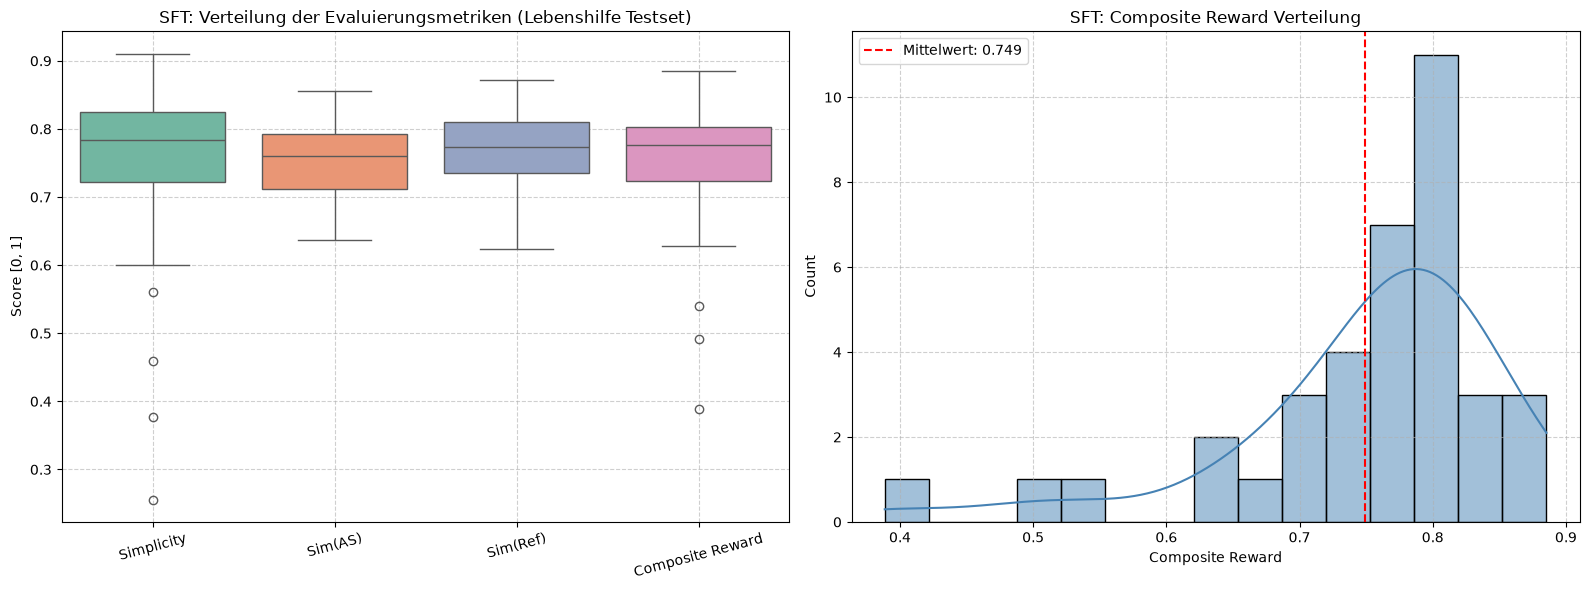

In [9]:
os.makedirs("results/plots", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot der Metriken
sns.boxplot(data=sft_eval_df[metrics_cols], ax=axes[0], palette="Set2")
axes[0].set_title("SFT: Verteilung der Evaluierungsmetriken (Lebenshilfe Testset)", fontsize=12)
axes[0].set_ylabel("Score [0, 1]")
axes[0].set_xticks(range(len(metrics_cols)))
axes[0].set_xticklabels(["Simplicity", "Sim(AS)", "Sim(Ref)", "Composite Reward"], rotation=15)
axes[0].grid(True, linestyle="--", alpha=0.6)

# KDE / Histogramm des Composite Rewards
sns.histplot(sft_eval_df["composite_reward"], kde=True, ax=axes[1], color="steelblue", bins=15)
axes[1].axvline(sft_eval_df["composite_reward"].mean(), color="red", linestyle="--", label=f"Mittelwert: {sft_eval_df['composite_reward'].mean():.3f}")
axes[1].set_title("SFT: Composite Reward Verteilung", fontsize=12)
axes[1].set_xlabel("Composite Reward")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plot_out_path = "results/plots/sft_decoder_only_lebenshilfe_metrics.png"
plt.savefig(plot_out_path, dpi=300)
print(f"Plot gespeichert unter: {plot_out_path}")
plt.show()

## 9. Interaktiver Übersetzungstest

In [10]:
def translate_and_compare_sft_few_shot(text, temperature=0.2):
    print("=" * 75)
    print("[EINGABETEXT (AS)]:")
    print(text)
    print("=" * 75)
    
    # Few-Shot Baseline (Base Model)
    # Few-Shot Baseline (Qwen2.5-7B Base Model ohne Training)
    fs_gen = generate_few_shot_batch([text], temperature=temperature)[0]
    tot_r_fs, r_style_fs, r_sem_fs = reward_evaluator.compute_reward([text], [fs_gen])
    print("\n--- 1. FEW-SHOT BASELINE (Deutsches SauerkrautLM-8B ohne Training) ---")
    print(fs_gen)
    print(f"[Scores]: Simplicity={r_style_fs[0]:.3f} | SBERT(AS)={r_sem_fs[0]:.3f} | Total Reward={tot_r_fs[0]:.3f}")
    
    # SFT Model
    sft_gen = generate_sft_decoder_batch(sft_model, tokenizer, [text], temperature=temperature)[0]
    tot_r_sft, r_style_sft, r_sem_sft = reward_evaluator.compute_reward([text], [sft_gen])
    print("\n--- 2. SFT MODELL (LoRA Fine-Tuned) ---")
    print(sft_gen)
    print(f"[Scores]: Simplicity={r_style_sft[0]:.3f} | SBERT(AS)={r_sem_sft[0]:.3f} | Total Reward={tot_r_sft[0]:.3f}")
    print("=" * 75)

# Beispiel testen:
test_input = "Hunde (Canis lupus familiaris) begleiten den Menschen seit Jahrtausenden und gelten als das älteste domestizierte Haustier. Sie stammen vom Wolf ab und haben sich im Laufe der Zeit perfekt an das Leben mit uns angepasst. Heute sind sie nicht nur beliebte Haustiere, sondern oft vollwertige Familienmitglieder, ausdauernde Arbeitstiere und therapeutische Helfer."
translate_and_compare_sft_few_shot(test_input);

[EINGABETEXT (AS)]:
Hunde (Canis lupus familiaris) begleiten den Menschen seit Jahrtausenden und gelten als das älteste domestizierte Haustier. Sie stammen vom Wolf ab und haben sich im Laufe der Zeit perfekt an das Leben mit uns angepasst. Heute sind sie nicht nur beliebte Haustiere, sondern oft vollwertige Familienmitglieder, ausdauernde Arbeitstiere und therapeutische Helfer.

--- 1. FEW-SHOT BASELINE (Deutsches SauerkrautLM-8B ohne Training) ---
Der Hund lebt lange Zeit mit Menschen gemeinsam. Er ist das erste Haustierschaf aller Zeiten. Der Hund kam vom Wolfs-Urtyp her. Über viele Jahre passten Hunde sich unserem Leben an. Heutzutage lieben wir Hunden sehr viel. Viele Hunde gehören sogar zur Familie, arbeiten hart oder helfen in der Therapiezimmern.
[Scores]: Simplicity=0.623 | SBERT(AS)=0.857 | Total Reward=0.693

--- 2. SFT MODELL (LoRA Fine-Tuned) ---
Die Hundehälfte von einem Wolf Die Hundehälften von einer Wolfs-Haus-Schwester Das Tier kann man auch so nennen: Canis Lupus Fam